<a href="https://colab.research.google.com/github/pranjal-coders/PRANJAL_PAL/blob/main/EDA_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# NAME : PRANJAL PAL
# REG. NO. : 23BDS0148
# EDA COURSE PROJECT - PHASE 1
# Dataset: PhD Publications Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
# TASK 1: LOADING THE DATASET
print("=== TASK 1: LOADING DATASET ===")
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/PhDPublications.csv"
df = pd.read_csv(url)

# Clean up index column if present from R CSV output
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Dataset successfully loaded. Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

=== TASK 1: LOADING DATASET ===
Dataset successfully loaded. Shape: (915, 7)

First 5 rows:
   rownames  articles  gender married  kids  prestige  mentor
0         1         0    male     yes     0      2.52       7
1         2         0  female      no     0      2.05       6
2         3         0  female      no     0      3.75       6
3         4         0    male     yes     1      1.18       3
4         5         0  female      no     0      3.75      26


In [5]:
# TASK 2: BASIC STATISTICAL ANALYSIS
print("\n=== TASK 2: BASIC STATISTICAL ANALYSIS ===")

print("\n--- Dataframe Info ---")
df.info()

print("\n--- Summary Statistics (Numerical & Categorical) ---")
print(df.describe(include="all"))

print("\n--- Skewness of Numerical Features ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].skew())


=== TASK 2: BASIC STATISTICAL ANALYSIS ===

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  915 non-null    int64  
 1   articles  915 non-null    int64  
 2   gender    915 non-null    object 
 3   married   915 non-null    object 
 4   kids      915 non-null    int64  
 5   prestige  915 non-null    float64
 6   mentor    915 non-null    int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 50.2+ KB

--- Summary Statistics (Numerical & Categorical) ---
          rownames    articles gender married        kids    prestige  \
count   915.000000  915.000000    915     915  915.000000  915.000000   
unique         NaN         NaN      2       2         NaN         NaN   
top            NaN         NaN   male     yes         NaN         NaN   
freq           NaN         NaN    494     606         NaN         Na

In [6]:
# TASK 3: HANDLING MISSING DATA
print("\n=== TASK 3: HANDLING MISSING DATA ===")
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({"Missing Values": missing_count, "Percentage (%)": missing_pct})
print(missing_df)

# Imputation logic if missing values exist
if missing_count.sum() > 0:
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values handled using median/mode imputation.")
else:
    print("No missing values detected in the dataset.")


=== TASK 3: HANDLING MISSING DATA ===
          Missing Values  Percentage (%)
rownames               0             0.0
articles               0             0.0
gender                 0             0.0
married                0             0.0
kids                   0             0.0
prestige               0             0.0
mentor                 0             0.0
No missing values detected in the dataset.


In [7]:
# TASK 4: DATA CLEANING
print("\n=== TASK 4: DATA CLEANING ===")

# Check duplicates
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")

# Strip whitespace from categorical strings
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

print("Data types after cleaning:")
print(df.dtypes)


=== TASK 4: DATA CLEANING ===
Duplicate rows found: 0
Data types after cleaning:
rownames      int64
articles      int64
gender       object
married      object
kids          int64
prestige    float64
mentor        int64
dtype: object


In [8]:
# TASK 5: DATA TRANSFORMATION
print("\n=== TASK 5: DATA TRANSFORMATION ===")

# 1. Binary Encoding for categorical variables
df_transformed = df.copy()
if 'gender' in df_transformed.columns:
    df_transformed['gender_encoded'] = df_transformed['gender'].map({'female': 1, 'male': 0})
if 'married' in df_transformed.columns:
    df_transformed['is_married'] = df_transformed['married'].map({'yes': 1, 'no': 0})

# 2. Log transformation on highly skewed target variable ('articles')
df_transformed['articles_log'] = np.log1p(df_transformed['articles'])

# 3. Feature Engineering: Article-to-Mentor Ratio
df_transformed['articles_per_mentor_pub'] = df_transformed['articles'] / (df_transformed['mentor'] + 1)

print("Engineered and transformed features added:")
print(df_transformed[['articles', 'articles_log', 'articles_per_mentor_pub']].head())


=== TASK 5: DATA TRANSFORMATION ===
Engineered and transformed features added:
   articles  articles_log  articles_per_mentor_pub
0         0           0.0                      0.0
1         0           0.0                      0.0
2         0           0.0                      0.0
3         0           0.0                      0.0
4         0           0.0                      0.0



=== TASK 6: UNIVARIATE ANALYSIS ===


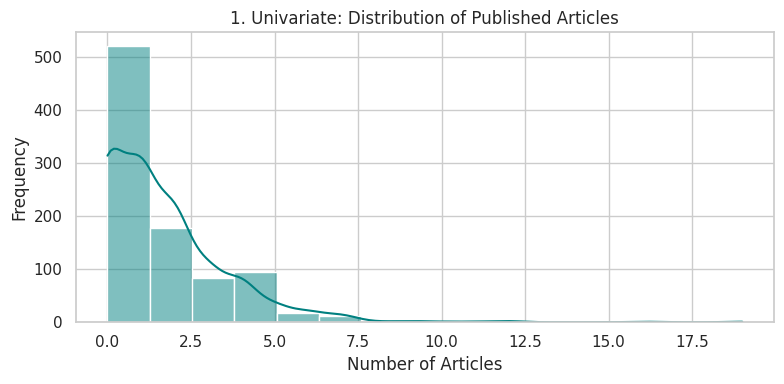

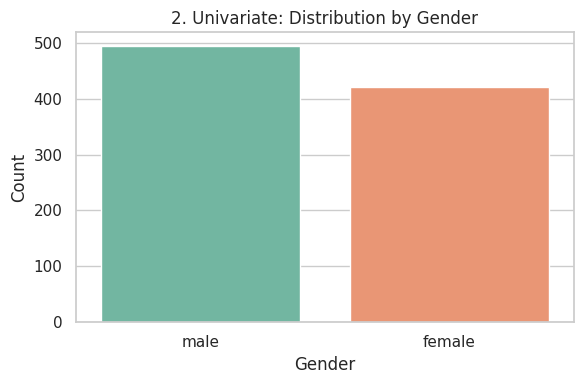

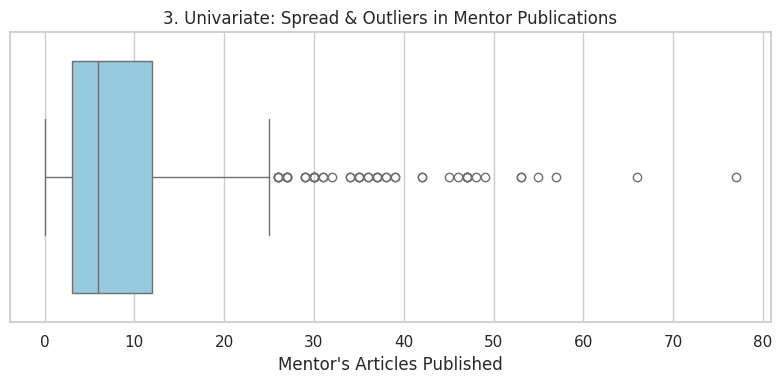

In [9]:
# TASK 6: UNIVARIATE ANALYSIS (WARNING-FREE)
print("\n=== TASK 6: UNIVARIATE ANALYSIS ===")

# Vis 1: Distribution of Target Variable (Articles)
plt.figure(figsize=(8, 4))
sns.histplot(df['articles'], kde=True, bins=15, color='teal')
plt.title("1. Univariate: Distribution of Published Articles")
plt.xlabel("Number of Articles")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Vis 2: Countplot of Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='gender', palette='Set2', legend=False)
plt.title("2. Univariate: Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Vis 3: Boxplot of Mentor Article Output
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['mentor'], color='skyblue')
plt.title("3. Univariate: Spread & Outliers in Mentor Publications")
plt.xlabel("Mentor's Articles Published")
plt.tight_layout()
plt.show()


=== TASK 7: BIVARIATE ANALYSIS ===


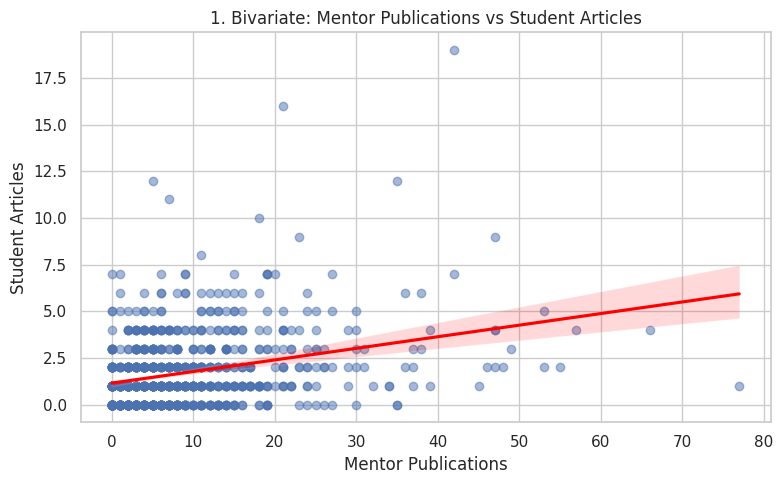

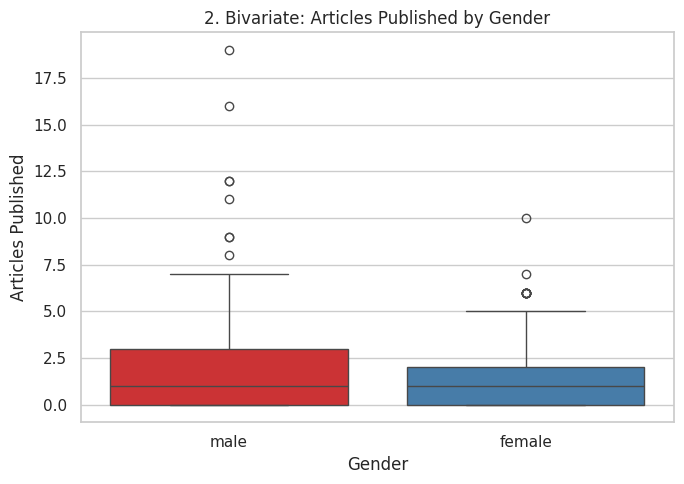

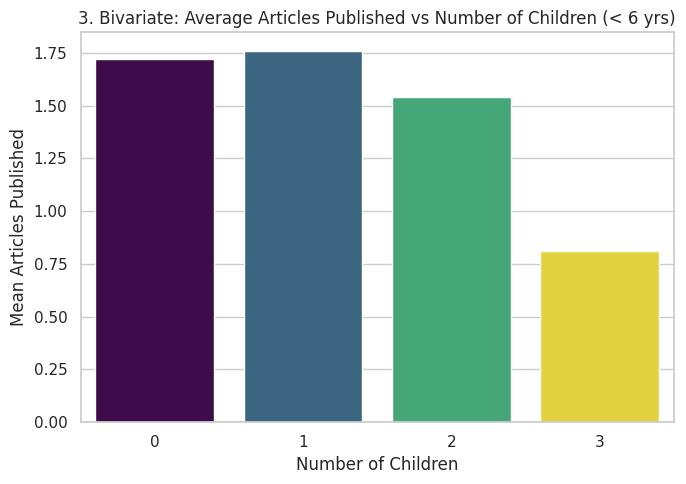

In [10]:
# TASK 7: BIVARIATE ANALYSIS
print("\n=== TASK 7: BIVARIATE ANALYSIS ===")

# Vis 1: Mentor Publications vs Student Articles (Scatter Plot + Regression)
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='mentor', y='articles', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title("1. Bivariate: Mentor Publications vs Student Articles")
plt.xlabel("Mentor Publications")
plt.ylabel("Student Articles")
plt.tight_layout()
plt.show()

# Vis 2: Student Articles Published by Gender (Box Plot)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='gender', y='articles', hue='gender', palette='Set1', legend=False)
plt.title("2. Bivariate: Articles Published by Gender")
plt.xlabel("Gender")
plt.ylabel("Articles Published")
plt.tight_layout()
plt.show()

# Vis 3: Average Articles Published by Number of Young Children (Bar Plot)
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='kids', y='articles', hue='kids', errorbar=None, palette='viridis', legend=False)
plt.title("3. Bivariate: Average Articles Published vs Number of Children (< 6 yrs)")
plt.xlabel("Number of Children")
plt.ylabel("Mean Articles Published")
plt.tight_layout()
plt.show()


=== TASK 8: MULTIVARIATE ANALYSIS ===


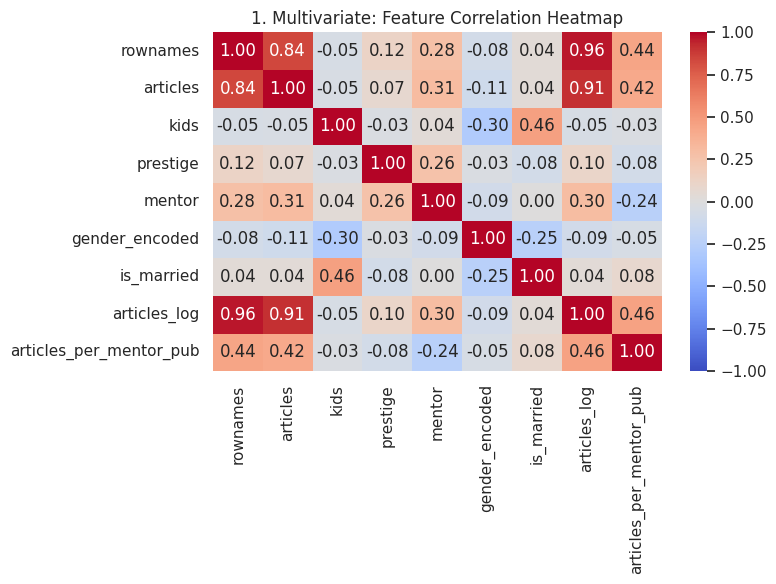

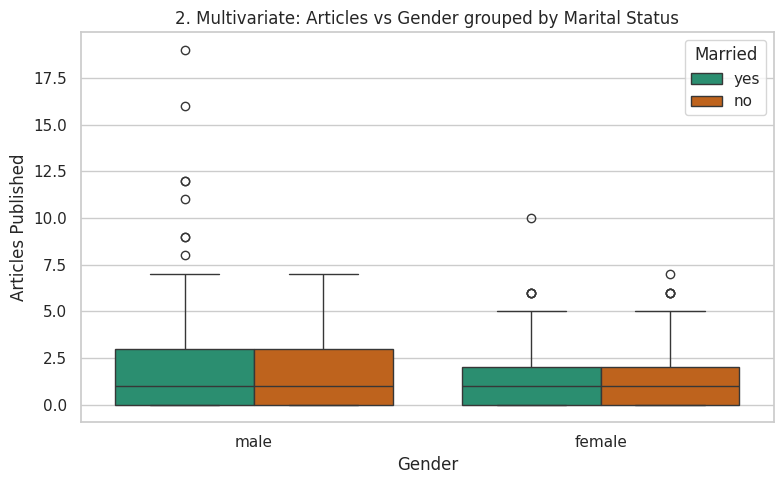

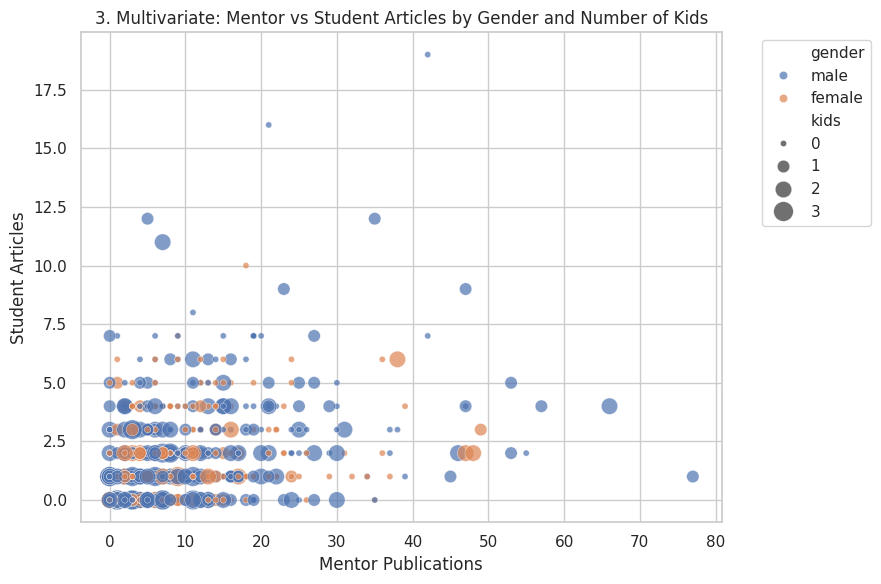


=== PHASE 1 ANALYSIS COMPLETE ===


In [11]:
# TASK 8: MULTIVARIATE ANALYSIS (3 VISUALIZATIONS)
print("\n=== TASK 8: MULTIVARIATE ANALYSIS ===")

# Vis 1: Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df_transformed.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("1. Multivariate: Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Vis 2: Articles by Gender and Marital Status (Catplot / Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gender', y='articles', hue='married', palette='Dark2')
plt.title("2. Multivariate: Articles vs Gender grouped by Marital Status")
plt.xlabel("Gender")
plt.ylabel("Articles Published")
plt.legend(title="Married")
plt.tight_layout()
plt.show()

# Vis 3: Mentor Publications vs Student Articles by Gender & Kids
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='mentor', y='articles', hue='gender', size='kids', sizes=(20, 200), alpha=0.7)
plt.title("3. Multivariate: Mentor vs Student Articles by Gender and Number of Kids")
plt.xlabel("Mentor Publications")
plt.ylabel("Student Articles")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n=== PHASE 1 ANALYSIS COMPLETE ===")

In [12]:
# ============================================================
# PHASE II - 1D STATISTICAL ANALYSIS
# ============================================================

print("========== 1D STATISTICAL ANALYSIS ==========")

# Select numerical columns
numeric_cols = ["articles", "kids", "prestige", "mentor"]

# Mean
print("\n--- Mean ---")
print(df[numeric_cols].mean())

# Median
print("\n--- Median ---")
print(df[numeric_cols].median())

# Mode
print("\n--- Mode ---")
print(df[numeric_cols].mode().iloc[0])

# Variance
print("\n--- Variance ---")
print(df[numeric_cols].var())

# Standard Deviation
print("\n--- Standard Deviation ---")
print(df[numeric_cols].std())

# Minimum
print("\n--- Minimum ---")
print(df[numeric_cols].min())

# Maximum
print("\n--- Maximum ---")
print(df[numeric_cols].max())

# Quartiles
print("\n--- Quartiles ---")
print(df[numeric_cols].quantile([0.25, 0.50, 0.75]))

# Skewness
print("\n--- Skewness ---")
print(df[numeric_cols].skew())

# Kurtosis
print("\n--- Kurtosis ---")
print(df[numeric_cols].kurtosis())

========== 1D STATISTICAL ANALYSIS ==========

--- Mean ---
articles    1.692896
kids        0.495082
prestige    3.103109
mentor      8.767213
dtype: float64

--- Median ---
articles    1.00
kids        0.00
prestige    3.15
mentor      6.00
dtype: float64

--- Mode ---
articles    0.00
kids        0.00
prestige    4.29
mentor      0.00
Name: 0, dtype: float64

--- Variance ---
articles     3.709742
kids         0.585041
prestige     0.968746
mentor      89.944657
dtype: float64

--- Standard Deviation ---
articles    1.926069
kids        0.764880
prestige    0.984249
mentor      9.483916
dtype: float64

--- Minimum ---
articles    0.000
kids        0.000
prestige    0.755
mentor      0.000
dtype: float64

--- Maximum ---
articles    19.00
kids         3.00
prestige     4.62
mentor      77.00
dtype: float64

--- Quartiles ---
      articles  kids  prestige  mentor
0.25       0.0   0.0      2.26     3.0
0.50       1.0   0.0      3.15     6.0
0.75       2.0   1.0      3.92    12.0

--- 

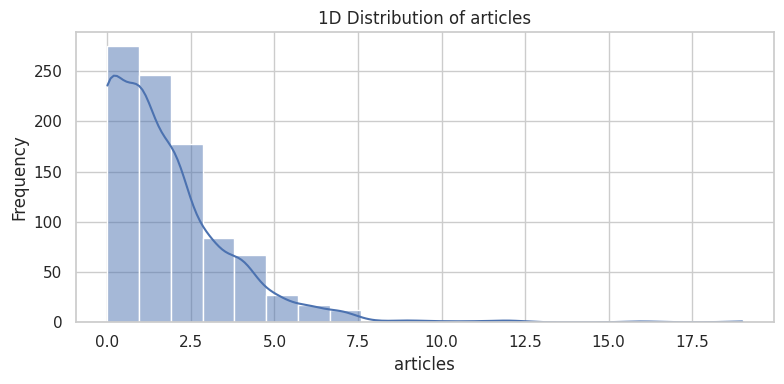

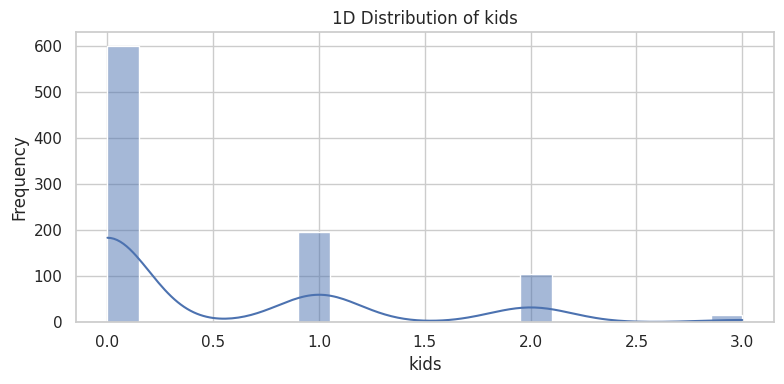

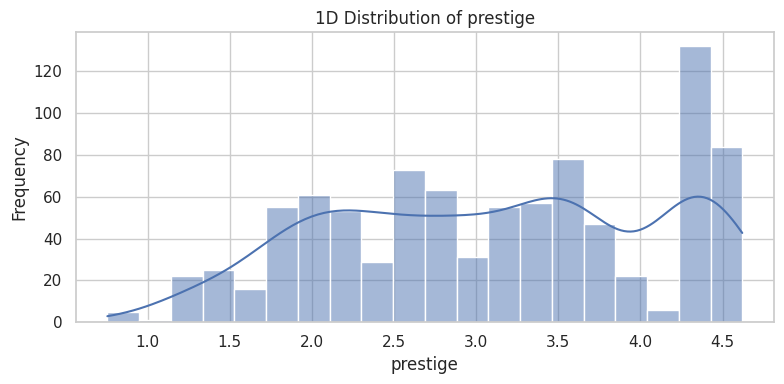

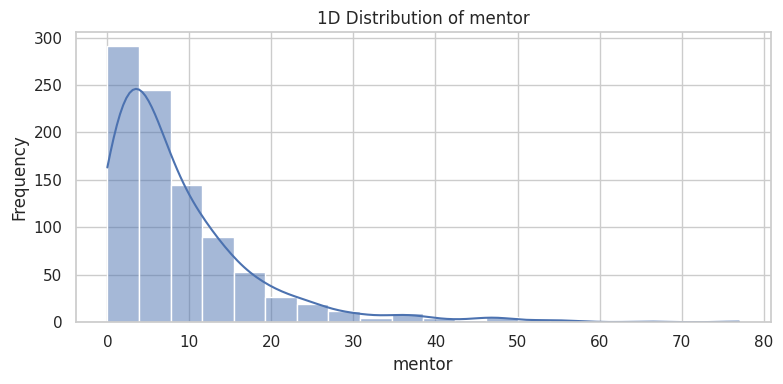

In [13]:
# 1D Statistical Visualization

for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(df[col], kde=True, bins=20)

    plt.title(f"1D Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

========== 2D STATISTICAL ANALYSIS ==========

--- Correlation Matrix ---
          articles      kids  prestige    mentor
articles  1.000000 -0.045214  0.073339  0.305862
kids     -0.045214  1.000000 -0.026506  0.037020
prestige  0.073339 -0.026506  1.000000  0.260414
mentor    0.305862  0.037020  0.260414  1.000000


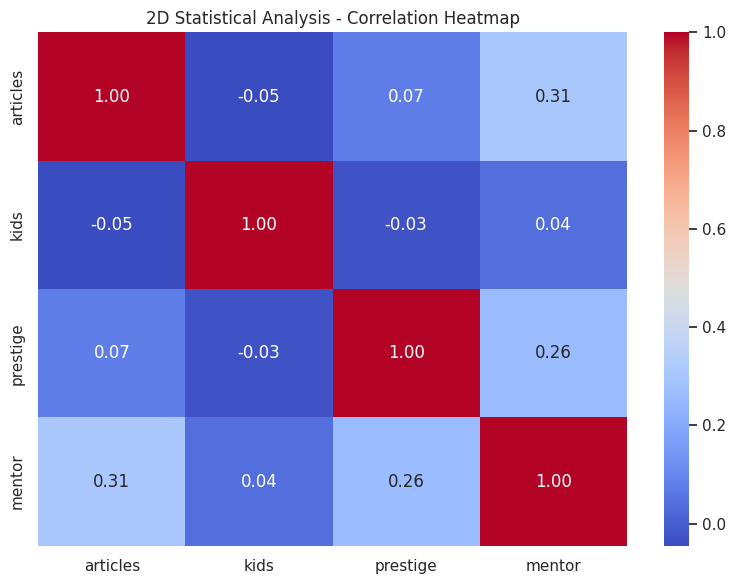

In [14]:
# ============================================================
# PHASE II - 2D STATISTICAL ANALYSIS
# ============================================================

print("========== 2D STATISTICAL ANALYSIS ==========")

# Correlation matrix
correlation_matrix = df[numeric_cols].corr()

print("\n--- Correlation Matrix ---")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("2D Statistical Analysis - Correlation Heatmap")
plt.tight_layout()
plt.show()

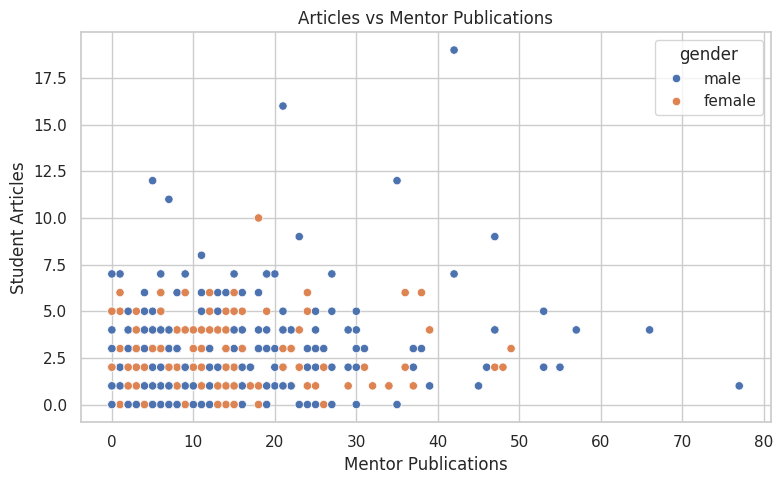

In [15]:
# Articles vs Mentor Publications

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='mentor',
    y='articles',
    hue='gender'
)

plt.title("Articles vs Mentor Publications")
plt.xlabel("Mentor Publications")
plt.ylabel("Student Articles")
plt.tight_layout()
plt.show()

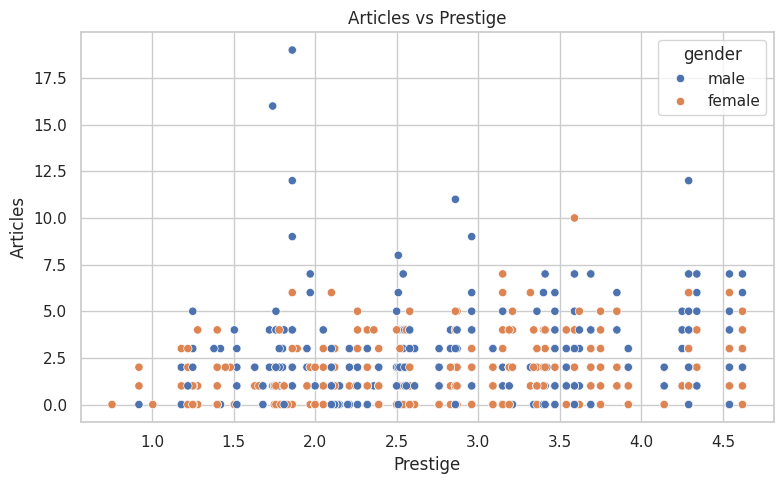

In [16]:
# Articles vs Prestige

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='prestige',
    y='articles',
    hue='gender'
)

plt.title("Articles vs Prestige")
plt.xlabel("Prestige")
plt.ylabel("Articles")
plt.tight_layout()
plt.show()

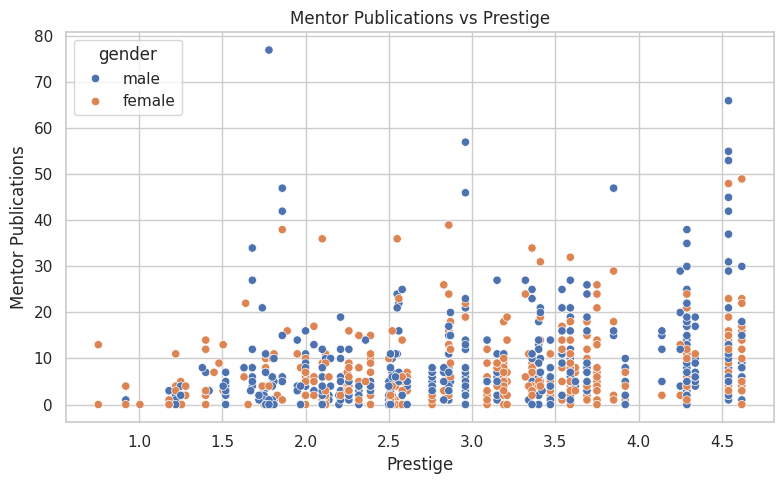

In [17]:
# Mentor vs Prestige

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='prestige',
    y='mentor',
    hue='gender'
)

plt.title("Mentor Publications vs Prestige")
plt.xlabel("Prestige")
plt.ylabel("Mentor Publications")
plt.tight_layout()
plt.show()

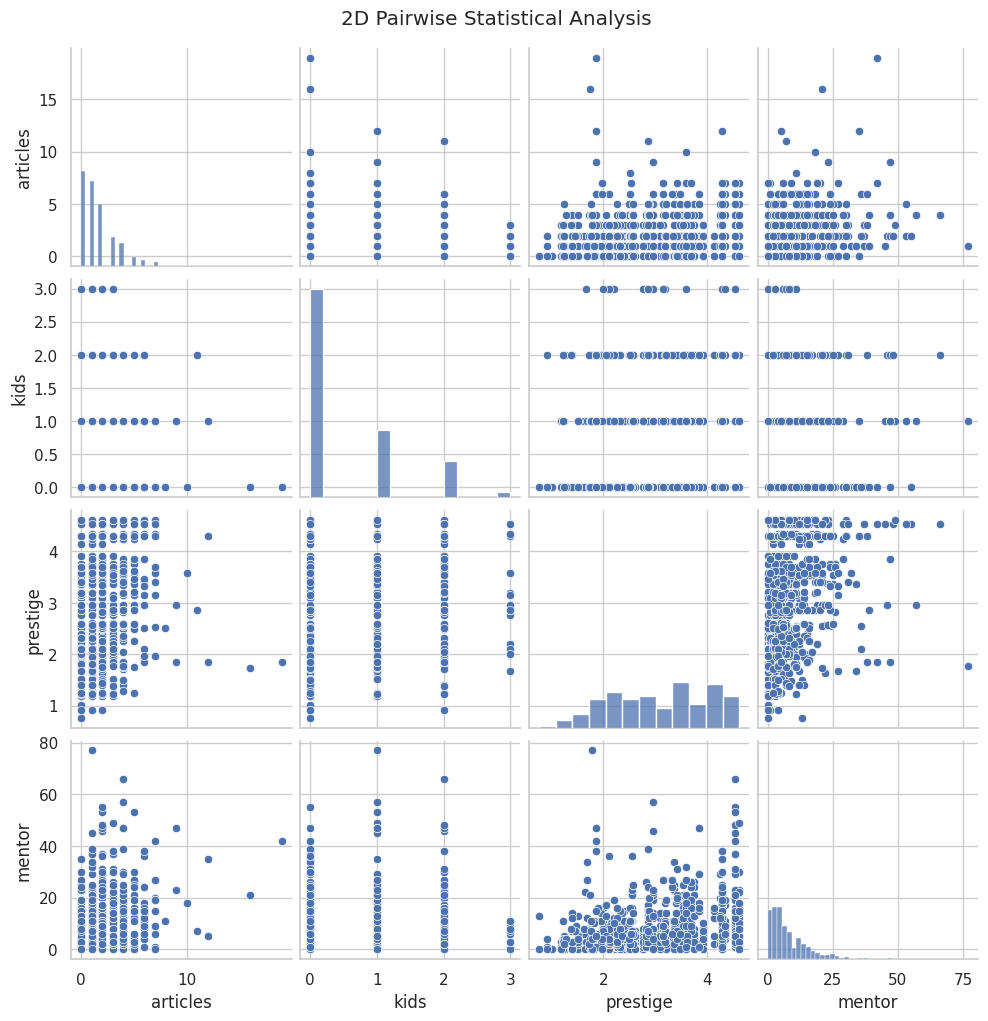

In [18]:
# Pairwise relationships between numerical variables

sns.pairplot(
    df[numeric_cols],
    diag_kind='hist'
)

plt.suptitle("2D Pairwise Statistical Analysis", y=1.02)
plt.show()

========== 3D STATISTICAL ANALYSIS ==========


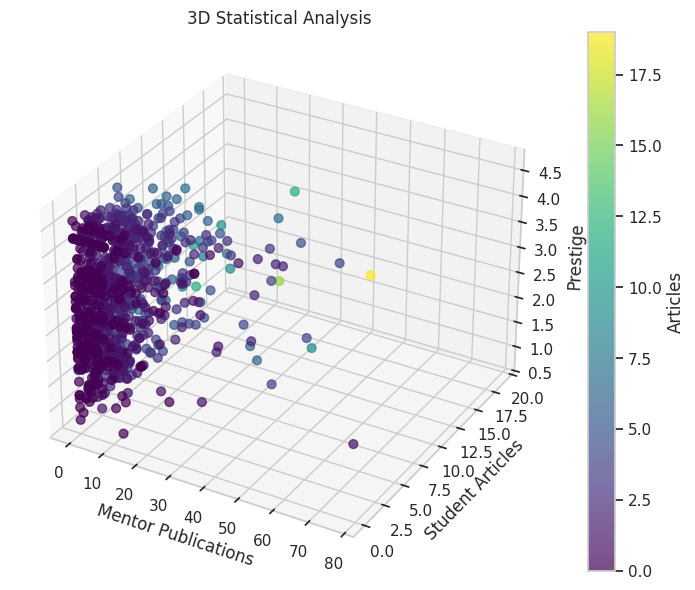

In [19]:
# ============================================================
# PHASE II - 3D STATISTICAL ANALYSIS
# ============================================================

print("========== 3D STATISTICAL ANALYSIS ==========")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['mentor'],
    df['articles'],
    df['prestige'],
    c=df['articles'],
    cmap='viridis',
    s=40,
    alpha=0.7
)

ax.set_xlabel("Mentor Publications")
ax.set_ylabel("Student Articles")
ax.set_zlabel("Prestige")

ax.set_title("3D Statistical Analysis")

plt.colorbar(scatter, label="Articles")

plt.show()

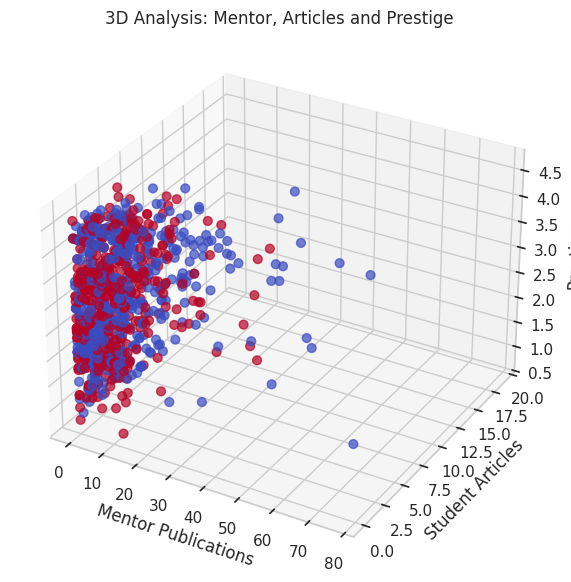

In [20]:
# Encode gender for 3D visualization

gender_numeric = df['gender'].map({
    'female': 1,
    'male': 0
})

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['mentor'],
    df['articles'],
    df['prestige'],
    c=gender_numeric,
    cmap='coolwarm',
    s=40,
    alpha=0.7
)

ax.set_xlabel("Mentor Publications")
ax.set_ylabel("Student Articles")
ax.set_zlabel("Prestige")

ax.set_title("3D Analysis: Mentor, Articles and Prestige")

plt.show()

In [21]:
# ============================================================
# PHASE II - K-MEANS CLUSTERING
# ============================================================

print("========== K-MEANS CLUSTERING ==========")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features for clustering
cluster_features = ['articles', 'kids', 'prestige', 'mentor']

X = df[cluster_features].copy()

print("\nFeatures selected for clustering:")
print(cluster_features)

# Standardize the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized data:")
print(X_scaled[:5])

========== K-MEANS CLUSTERING ==========

Features selected for clustering:
['articles', 'kids', 'prestige', 'mentor']

Standardized data:
[[-0.8794192  -0.64762148 -0.59276478 -0.18643983]
 [-0.8794192  -0.64762148 -1.07054736 -0.29193917]
 [-0.8794192  -0.64762148  0.65760236 -0.29193917]
 [-0.8794192   0.66048813 -1.95495338 -0.60843721]
 [-0.8794192  -0.64762148  0.65760236  1.81804773]]


In [23]:
# Apply K-Means clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['KMeans_Cluster'] = clusters

print("\nK-Means Cluster Labels:")
print(df['KMeans_Cluster'].value_counts().sort_index())


K-Means Cluster Labels:
KMeans_Cluster
0    265
1    204
2    446
Name: count, dtype: int64


In [24]:
# Cluster centers

cluster_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=cluster_features
)

print("\n--- Cluster Centers ---")
print(cluster_centers_df)


--- Cluster Centers ---
   articles          kids  prestige     mentor
0  1.166038  1.475472e+00  2.932585   6.347170
1  3.642157  3.039216e-01  3.862451  19.754902
2  1.114350  1.387779e-15  2.857108   5.179372


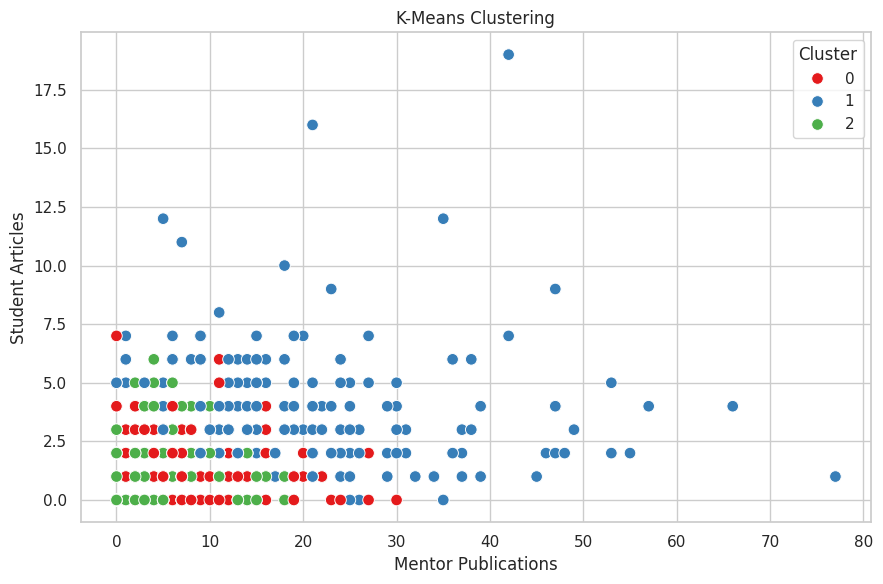

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='mentor',
    y='articles',
    hue='KMeans_Cluster',
    palette='Set1',
    s=70
)

plt.title("K-Means Clustering")
plt.xlabel("Mentor Publications")
plt.ylabel("Student Articles")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

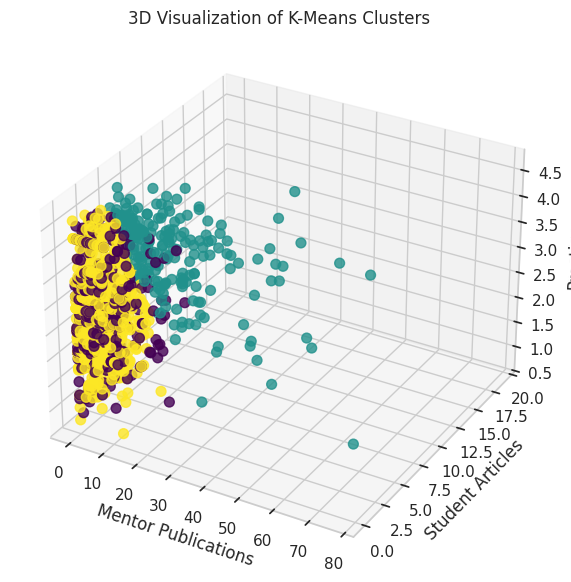

In [26]:
# 3D visualization of K-Means clusters

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['mentor'],
    df['articles'],
    df['prestige'],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    s=50,
    alpha=0.8
)

ax.set_xlabel("Mentor Publications")
ax.set_ylabel("Student Articles")
ax.set_zlabel("Prestige")

ax.set_title("3D Visualization of K-Means Clusters")

plt.show()

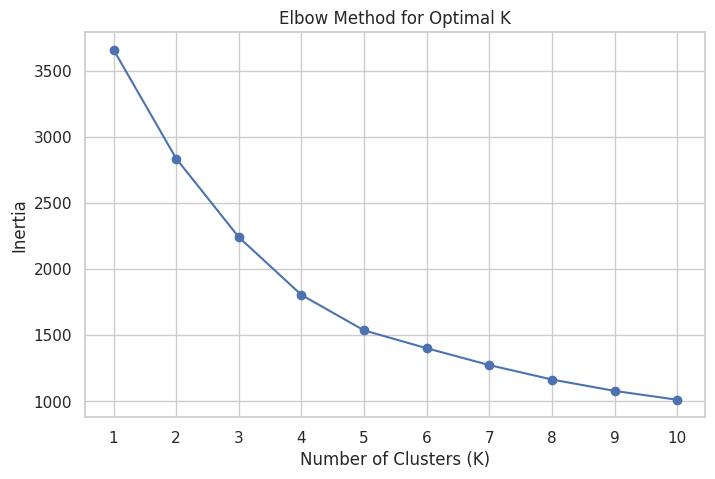

In [27]:
# ============================================================
# ELBOW METHOD FOR OPTIMAL K
# ============================================================

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_temp.fit(X_scaled)

    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(K_range)
plt.grid(True)

plt.show()

========== HIERARCHICAL CLUSTERING ==========


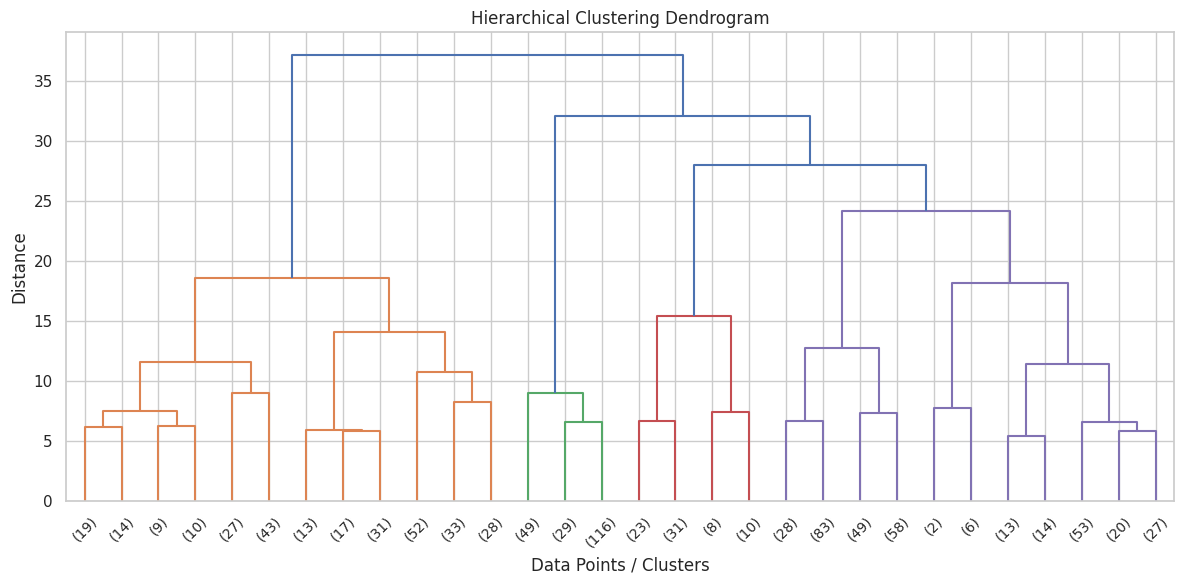

In [28]:
# ============================================================
# PHASE II - HIERARCHICAL CLUSTERING
# ============================================================

print("========== HIERARCHICAL CLUSTERING ==========")

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix
linkage_matrix = linkage(
    X_scaled,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

In [29]:
# Apply Agglomerative Hierarchical Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_clusters = hierarchical.fit_predict(X_scaled)

# Add cluster labels
df['Hierarchical_Cluster'] = hierarchical_clusters

print("\nHierarchical Cluster Distribution:")
print(
    df['Hierarchical_Cluster']
    .value_counts()
    .sort_index()
)


Hierarchical Cluster Distribution:
Hierarchical_Cluster
0    425
1    296
2    194
Name: count, dtype: int64


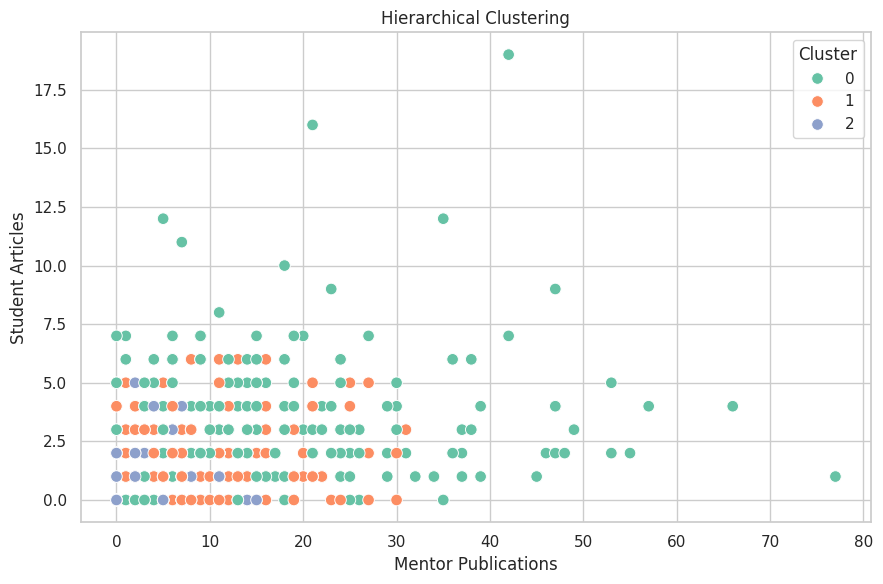

In [30]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='mentor',
    y='articles',
    hue='Hierarchical_Cluster',
    palette='Set2',
    s=70
)

plt.title("Hierarchical Clustering")
plt.xlabel("Mentor Publications")
plt.ylabel("Student Articles")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

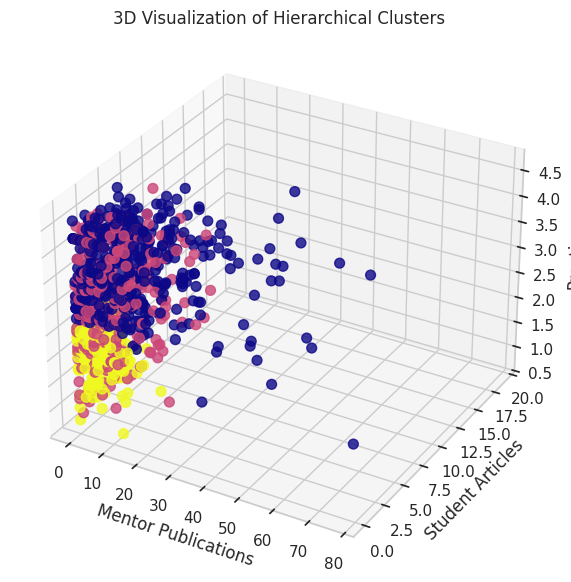

In [31]:
# 3D visualization of Hierarchical Clusters

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['mentor'],
    df['articles'],
    df['prestige'],
    c=df['Hierarchical_Cluster'],
    cmap='plasma',
    s=50,
    alpha=0.8
)

ax.set_xlabel("Mentor Publications")
ax.set_ylabel("Student Articles")
ax.set_zlabel("Prestige")

ax.set_title("3D Visualization of Hierarchical Clusters")

plt.show()

In [32]:
# ============================================================
# COMPARISON OF CLUSTERING METHODS
# ============================================================

print("========== CLUSTERING COMPARISON ==========")

comparison = pd.DataFrame({
    'KMeans': df['KMeans_Cluster'].value_counts().sort_index(),
    'Hierarchical': df['Hierarchical_Cluster'].value_counts().sort_index()
})

print(comparison)

========== CLUSTERING COMPARISON ==========
   KMeans  Hierarchical
0     265           425
1     204           296
2     446           194


In [33]:
# Display final dataset with cluster labels

print("\nFinal Dataset:")
print(
    df[
        [
            'articles',
            'gender',
            'married',
            'kids',
            'prestige',
            'mentor',
            'KMeans_Cluster',
            'Hierarchical_Cluster'
        ]
    ].head(10)
)


Final Dataset:
   articles  gender married  kids  prestige  mentor  KMeans_Cluster  \
0         0    male     yes     0      2.52       7               2   
1         0  female      no     0      2.05       6               2   
2         0  female      no     0      3.75       6               2   
3         0    male     yes     1      1.18       3               0   
4         0  female      no     0      3.75      26               1   
5         0  female     yes     2      3.59       2               0   
6         0  female      no     0      3.19       3               2   
7         0    male     yes     2      2.96       4               0   
8         0    male      no     0      4.62       6               2   
9         0  female     yes     0      1.25       0               2   

   Hierarchical_Cluster  
0                     2  
1                     2  
2                     0  
3                     1  
4                     0  
5                     1  
6                   